# 3. Determination of navigable season

The Lower Athabasca River is located in a cold region where below freezing temperatures cause the river to freeze during winter. Since the aim of this research is to analyse low flow navigation constraints, a consistent open water time window must be defined in which navigation restrictions are limited to discharge rather than ice formation. 

The timing of river ice break up and freeze up varies from year to year as the climate system is dynamic. Therefore, a simplified algorithm is developed to identify the approximate break up and freeze up dates for each year between 1970 and 2024. The algorithm is based on observed discharge data and temperature data from ERA5. The latest identified break up is used as the starting boundary of the fixed open water season, and the earliest identified freeze up date as the ending boundary. According to Peters et al., ice break up typically occurs in late April to early May, while freeze up may occur in late October to November (2023). These ranges are used as a reference to assess whether the algorithm produces realistic results.

Based on evaluations made in 3.1, start of navigable season and 3.2, end of navigable season, the study defines the navigational open water season as 18 May to 17 October. 

The same algorithms are applied to modelled future discharge and temperature data under climate scenarios to evaluate how the navigational period changes over time (See 6.2). 


## 3.1 Start of navigable season

The start of the navigable season is approximated using observed discharge at Fort McMurray, discharge station 07DA001. As temperatures begin to rise in spring, accumulated snow melts rapidly causing a significant increase in discharge. This period is called freshet and is often associated with increased flood risk. Once Qcritical is initially reached, low flows are unlikely to occur shortly after due to a continuous rise in discharge during freshet. Therefore, the first date each year on which discharge exceeds Qcritical is used as an indicator for the beginning of the open water analysis period. 

This method does not necessarily identify the exact date when all river ice has disappeared. Instead, it is used to prevent low flow days before the spring freshet from being included in the navigation analysis. This is important because discharge prior to break up may be low  due to low winter baseflow, while navigation is limited by ice. 

Figure 4 shows the first date each year when observed discharge exceeds the critical threshold. Most years fall between late April and early May, in line with expectations. The year 2009 forms an anomaly with 18 May identified as the start of freshet. Although this may be a late date, it is still considered suitable as the starting boundary. A later start date may help account for delayed modelled freshet peaks which the hydrological model is not specifically calibrated for (see chapter 4), preventing prior low baseflow days from being counted incorrectly. It is also notable that there is no visible indication of the start date changing over the years. 

Figure 5 gives one example year, illustrating the initial freshet period and how Qcritical is approached to identify the starting date.


In [71]:
# General python imports
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

In [72]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [73]:
# Defining time period & q_critical

experiment_start_date = "1970-01-01T00:00:00Z"
experiment_end_date = "2024-12-31T00:00:00Z"

q_critical = 500

hysets_id = "hysets_07DA001"
basin_size = 132572

In [74]:
# Loading in data

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "ERA5" / "ERA5-1970-2024"
forcing_path_ERA5.mkdir(exist_ok=True, parents=True)

discharge_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

# Load CSV discharge 07DA001
q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

In [75]:
# Filter q_obs to start & end date

start_date = pd.to_datetime(experiment_start_date.replace("Z", ""))
end_date = pd.to_datetime(experiment_end_date.replace("Z", ""))

q_obs = q_obs[
    (q_obs["Date"] >= start_date) &
    (q_obs["Date"] <= end_date)].copy()

In [76]:
# Create pd for identified critical dates

freshet_start_date = []

for year, group in q_obs.groupby(q_obs["Date"].dt.year):

    # Set start date to March 1
    start_date_algorithm = pd.to_datetime(f"{year}-03-01")
    season_data = group[group["Date"] >= start_date_algorithm].copy()
    
    # Identify first day where q > q_critical
    
    above_critical = season_data[
        season_data["discharge_m3s"] > q_critical]
    
    if len(above_critical) > 0:
        first_day = above_critical.iloc[0]
        
        freshet_start_date.append({
            "year": year,
            "first_above_critical_date": first_day["Date"],
            "discharge_m3s": first_day["discharge_m3s"]})

freshet_start_date = pd.DataFrame(freshet_start_date)

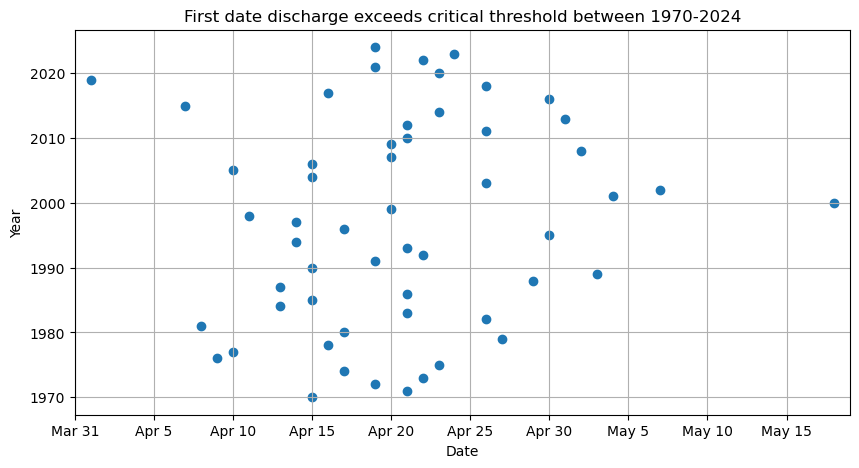

In [77]:
# Convert date to day of year
freshet_start_date["day_of_year"] = (freshet_start_date["first_above_critical_date"].dt.dayofyear)

# Make plot 
plt.figure(figsize=(10, 5))
plt.scatter(freshet_start_date["day_of_year"], freshet_start_date["year"], marker="o")

plt.xlabel("Date")
plt.ylabel("Year")
plt.title("First date discharge exceeds critical threshold between 1970-2024")
plt.grid(True)

# Convert day of year to day in months (on the axis)
plt.xticks(
    [60, 65, 70, 75, 80, 85, 90,
     95, 100, 105, 110, 115, 120,
     125, 130, 135, 140, 145, 150],
    ["Mar 1", "Mar 6", "Mar 11", "Mar 16", "Mar 21", "Mar 26", "Mar 31",
     "Apr 5", "Apr 10", "Apr 15", "Apr 20", "Apr 25", "Apr 30",
     "May 5", "May 10", "May 15", "May 20", "May 25", "May 30"],)

# Automate x-axis range to fit data
plt.xlim((freshet_start_date["day_of_year"].min()-1), (freshet_start_date["day_of_year"].max()+1))

plt.show()

**Figure 4:** Scatter plot showing yearly start of open-water season.


In [78]:
def plot_discharge_for_year(q_obs, freshet_start_date, q_critical, selected_year):

    # Define plotting period to selected year
    start_date = f"{selected_year}-01-01"
    end_date = f"{selected_year}-12-31"

    # Adjust q_obs and freshet_start_date to fit plotting period
    q_obs_year = q_obs[
        (q_obs["Date"] >= start_date) &
        (q_obs["Date"] <= end_date)]

    freshet_year = freshet_start_date[
        (freshet_start_date["first_above_critical_date"] >= start_date) &
        (freshet_start_date["first_above_critical_date"] <= end_date)]

    # Start figure
    plt.figure(figsize=(12, 5))

    # Plot q_obs
    plt.plot(q_obs_year["Date"], q_obs_year["discharge_m3s"], label="Observed discharge")

    # Plot q_critical
    plt.axhline(y=q_critical, linestyle=":", label=f"Critical discharge ({q_critical} m³/s)", color="black")

    # Plot when q_critical is reached
    for date in freshet_year["first_above_critical_date"].dropna():
        plt.axvline(x=date, linestyle=':', color='orange', label='Start navigable season')

    plt.xlabel("Date")
    plt.ylabel("Discharge (m³/s)")
    plt.title(f"Observed daily discharge at 07DA001 in {selected_year}")

    plt.legend()
    plt.show()

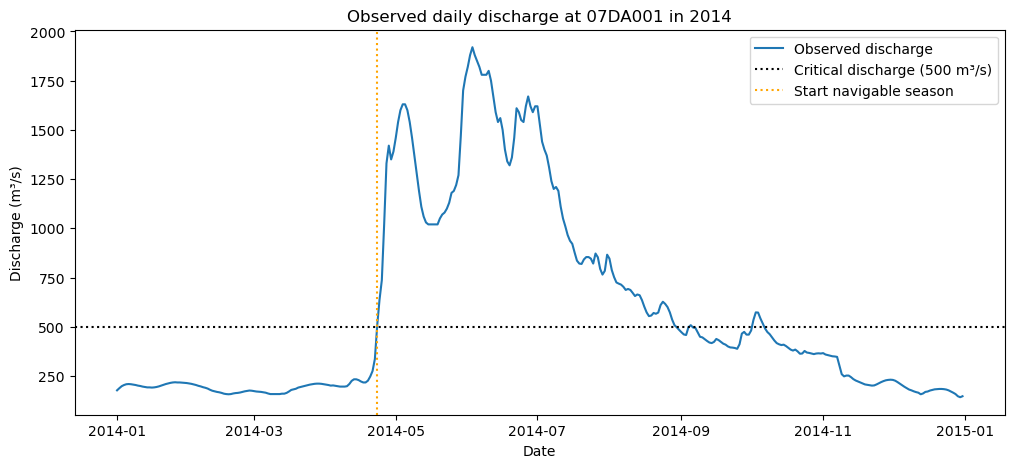

In [79]:
selected_year = 2014

plot_discharge_for_year(q_obs, freshet_start_date, q_critical, selected_year)

**Figure 5:** Graph showing first time Q reaches Q critical in 2014. 


## 3.1 End of navigable season

The end of the open water season is approximated using accumulated freezing degree days (AFDD), calculated from ERA5 2 m above surface temperature. AFDD is calculated by accumulating daily temperatures below 0 ℃. If the daily temperature is below 0 ℃, the absolute temperature is added to the cumulative AFDD. If the temperature is above 0 ℃, no value is added.

In the LAR there is a correlation between AFDD and ice formation. Andrishak reports that initial ice formation occurs around 10-12 ℃ AFDD, while complete ice cover forms around 50-52 ℃ AFDD (2008). Initial ice is likely to form near shallow river banks which may not immediately limit navigation. However, navigation may become constricted before a complete ice cover has formed. Therefore, this study assumes navigation becomes limited at a threshold of:

$AFDD > 30 ℃$

The AFDD is calculated from 1 October onwards to eliminate freeze degree day anomalies in prior months. A more detailed ice freeze up study could use net freezing degree days rather than cumulative freeze degree days, as this would reduce the influence of warmer periods in between cold spells. However, this lies outside the scope of this research. To remain consistent with Andrishak’s finding, AFDD is used. 

Figure 6 shows the estimated freeze up date for each year. Most identified dates occur between mid October to early November, in line with expectations. One clear outlier is 2009 with a freeze up date of 12 October. This outlier will not be used as the end of the navigation period because it falls 5 days before the next datapoint (1992, 17 October), which for all the other years is a relevant evaluation period for navigation. 

Figure 7 shows the temperature time series for an example year, 2014, illustrating how the freeze up date is determined using AFDD.

In [80]:
# Generate ERA5 data

# ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
#     dataset="ERA5",
#     start_time=experiment_start_date,
#     end_time=experiment_end_date,
#     shape=shape_file,
#     directory=forcing_path_ERA5
# )

# Load ERA5 data

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_ERA5)

In [81]:
# Exract tas file from Era5
tas_file = Path(ERA5_forcing.directory) / ERA5_forcing.filenames["tas"]

# Extract tas data from tas file
temp_data = xr.open_dataset(tas_file)["tas"]

# Convert to panda
temp_data = temp_data.to_series()
temp_data.index = pd.to_datetime(temp_data.index).tz_localize(None).normalize()

# Convert Kelvin to Celsius:
temp_data = temp_data - 273.15

# Create dataframe with Date, Temp & year as columns
temp_data = pd.DataFrame({
    "Date": temp_data.index,
    "Temp": temp_data.values,
    "year": temp_data.index.year})

In [82]:
AFDD_critical = 30
AFDD_critical_dates = []

start_year = start_date.year
end_year = end_date.year

for year in range(start_year, end_year + 1):

    # Set start date to 1 October
    year_data = temp_data[
        (temp_data["year"] == year) &
        (temp_data["Date"] >= pd.to_datetime(f"{year}-10-01"))]

    AFDD = 0
    
    # Isolate datasets of date & temperature data to each year 
    for i in range(len(year_data)):
        temp = year_data.iloc[i]["Temp"]
        date = year_data.iloc[i]["Date"]

        # Cumulative AFDD
        if temp < 0:
            AFDD += -temp

        # Append when AFDD is critical
        if AFDD >= AFDD_critical:
            AFDD_critical_dates.append({
                "year": year,
                "AFDD_critical_date": date,
                "AFDD": AFDD,
                "Temp": temp
            })

            break 

AFDD_critical_dates = pd.DataFrame(AFDD_critical_dates)

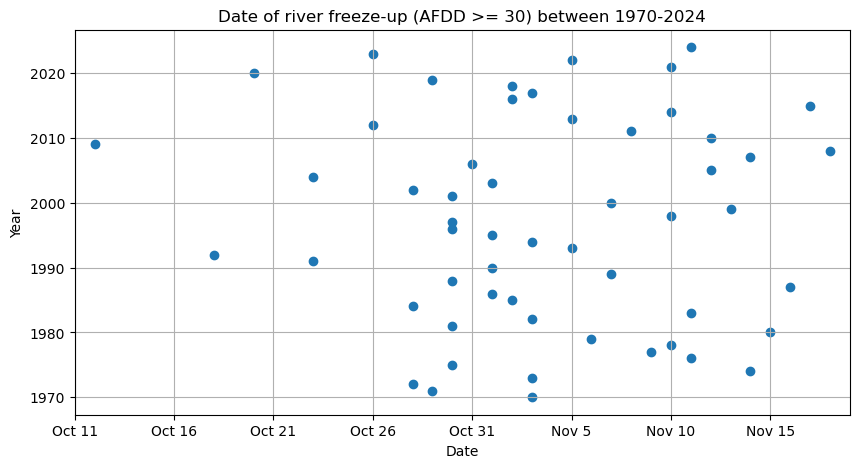

In [83]:
# Convert date to day of year
AFDD_critical_dates["day_of_year"] = (AFDD_critical_dates["AFDD_critical_date"].dt.dayofyear)

# Make plot 
plt.figure(figsize=(10, 5))
plt.scatter(AFDD_critical_dates["day_of_year"], AFDD_critical_dates["year"], marker="o")

plt.xlabel("Date")
plt.ylabel("Year")
plt.title(f"Date of river freeze-up (AFDD >= {AFDD_critical}) between 1970-2024")
plt.grid(True)

# Convert day of year to day in months (on the axis)
plt.xticks(
    [274, 279, 284, 289, 294, 299, 304,
     309, 314, 319, 324, 329, 334, 339,
     344, 349, 354, 359, 364, 366],
    ["Oct 1", "Oct 6", "Oct 11", "Oct 16", "Oct 21", "Oct 26", "Oct 31",
     "Nov 5", "Nov 10", "Nov 15", "Nov 20", "Nov 25", "Nov 30", "Dec 5",
     "Dec 10", "Dec 15", "Dec 20", "Dec 25", "Dec 30", "Dec 31"],)

# Automate x-axis range to fit data
plt.xlim((AFDD_critical_dates["day_of_year"].min()-1), (AFDD_critical_dates["day_of_year"].max()+1))

plt.show()

**Figure 6:** Scatter plot showing yearly end of open-water season.

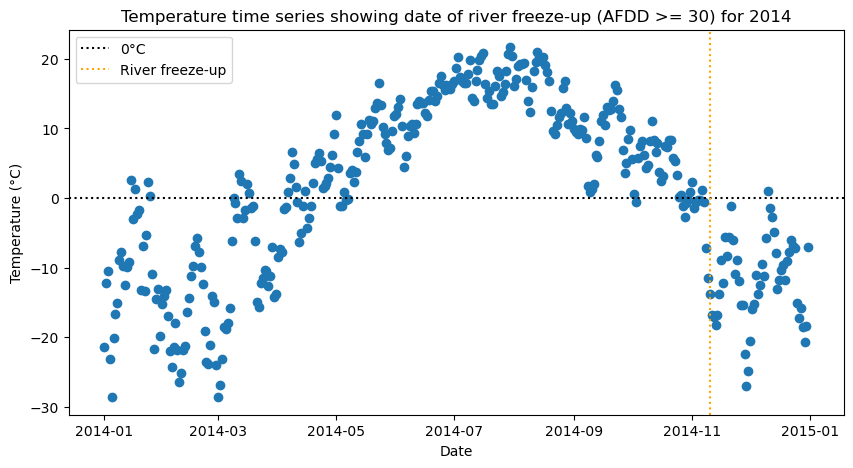

In [84]:
# Plot temp for 1 year for fun:
selected_year = 2014
year_data = temp_data[temp_data["year"] == selected_year]

plt.figure(figsize=(10, 5))
plt.title(f"Temperature time series showing date of river freeze-up (AFDD >= {AFDD_critical}) for 2014")
plt.scatter(year_data["Date"], year_data["Temp"], marker="o")
plt.axhline(y=0, linestyle=":", color="black", label="0°C")

# Extract & plot critical AFDD date for selected year
AFDD_critical_date = AFDD_critical_dates.loc[AFDD_critical_dates["year"] == selected_year, "AFDD_critical_date"].iloc[0]
plt.axvline(x=AFDD_critical_date, linestyle=":", color="orange", label="River freeze-up")

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

**Figure 7:** Graph showing temperature time series showing river freeze-up date for 2014.